### Testing SlideRule parameters that David suggested to use instead of confidence for filtering data. These comments were made on 1/28/2026. 

The conclusion I made was that I won't change any of the parameters that I'm currently using - keep using high confidence photons and don't need to filter on other attributes other than slope.

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd

# Imports
import time
from sliderule import sliderule, icesat2
import seaborn

In [91]:
sierras_full = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

In [ ]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [3]:
def download_icesat2(region, start_date, end_date):

    # Initialization
    #sliderule.init("sliderule-blue", verbose=True)
    icesat2.init("slideruleearth.io", verbose=True)

    # Parameters
    parms = {
        "poly": region,
        "srt": icesat2.SRT_LAND,
        #"cnf": icesat2.CNF_SURFACE_LOW, #As of 1/28/2026 David Shean recommends sticking with the default, to keep as much data as possible
        "atl08_class": "atl08_ground",
        "ats": 10.0,
        "cnt": 10,
        "len": 40.0,
        "res": 20.0,
        #"fit": {"maxi": 10}, #As of 1/28/2026 David Shean recommends sticking with the default maxi, which is 5
        "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
        "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "slope_aspect":True, "force_single_sample":True}},
        't0': start_date,
        't1': end_date
    }

    # Latch Start Time
    perf_start = time.perf_counter()

    # Request ATL06 Data
    gdf = sliderule.run("atl03x", parms) #, resources=["ATL03_20210309052953_11491002_006_01.h5"])

    # Latch Stop Time
    perf_stop = time.perf_counter()

    # Display Statistics
    perf_duration = perf_stop - perf_start
    print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
    print("Reference Ground Tracks: {}".format(gdf["rgt"].unique()))
    print("Cycles: {}".format(gdf["cycle"].unique()))
    print("Received {} elevations".format(gdf.shape[0]))

    return gdf

In [4]:
# Area of Interest
south_region = [
    {"lon": -120.2, "lat": 34.818611},
    {"lon": -117.862654, "lat": 34.818611},
    {"lon": -117.862654, "lat": 37.5},
    {"lon": -120.2, "lat": 37.5},
    {"lon": -120.2, "lat": 34.818611}
]

In [5]:
south_sierras_2021 = download_icesat2(south_region, '2020-07-30T08:00:00Z', '2020-08-30T08:00:00Z')

Completed in 71.666 seconds of wall-clock time
Reference Ground Tracks: [1004  562  623  646  707  768]
Cycles: [8]
Received 8928179 elevations


In [6]:
south_sierras_2021['icesat2_3dep_dif'] = south_sierras_2021['height'] - south_sierras_2021['3dep.value']

### test the accuracy of different photon confidence levels

In [11]:
import numpy as np
import pandas as pd

def summarize_stats(df, col='icesat2_3dep_dif'):
    return {
        'median': np.median(df[col]),
        'spread': np.std(df[col]),
        'sample_size': len(df[col])
    }

results = {}

# Test for all slope values
for cnf_val in [2, 3, 4]:
    mask = south_sierras_2021['atl03_cnf'] == cnf_val
    results[f'cnf_{cnf_val}_all_slope'] = summarize_stats(south_sierras_2021[mask])

# Only add one of these, since they are identical if cnf values are only 2,3,4
results['all_cnf_all_slope'] = summarize_stats(south_sierras_2021)

results['cnf_gt2_all_slope'] = summarize_stats(south_sierras_2021[south_sierras_2021['atl03_cnf'] > 2])
# results['cnf_gt3_all_slope'] = summarize_stats(south_sierras_2021[south_sierras_2021['atl03_cnf'] > 3])  # redundant with cnf_4_all_slope

# Test for 3dep.slope < 20
slope_mask = south_sierras_2021['3dep.deriv.slope'] < 20
for cnf_val in [2, 3, 4]:
    mask = (south_sierras_2021['atl03_cnf'] == cnf_val) & slope_mask
    results[f'cnf_{cnf_val}_slope_lt20'] = summarize_stats(south_sierras_2021[mask])

# Only add one of these, since they are identical if cnf values are only 2,3,4
results['all_cnf_slope_lt20'] = summarize_stats(south_sierras_2021[slope_mask])

results['cnf_gt2_slope_lt20'] = summarize_stats(south_sierras_2021[(south_sierras_2021['atl03_cnf'] > 2) & slope_mask])
# results['cnf_gt3_slope_lt20'] = summarize_stats(south_sierras_2021[(south_sierras_2021['atl03_cnf'] > 3) & slope_mask])  # redundant with cnf_4_slope_lt20

pd.DataFrame(results).T

,median,spread,sample_size
cnf_2_all_slope,-0.272687,2.733809,564419.0
cnf_3_all_slope,-0.032525,1.759831,872026.0
cnf_4_all_slope,-0.034425,1.858316,7491734.0
all_cnf_all_slope,-0.038541,1.920650,8928179.0
cnf_gt2_all_slope,-0.034291,1.848322,8363760.0
cnf_2_slope_lt20,-0.147182,1.632320,372538.0
cnf_3_slope_lt20,-0.024102,1.177010,741743.0
cnf_4_slope_lt20,-0.031479,1.536953,6962799.0
all_cnf_slope_lt20,-0.032975,1.512579,8077080.0
cnf_gt2_slope_lt20,-0.030977,1.506086,7704542.0


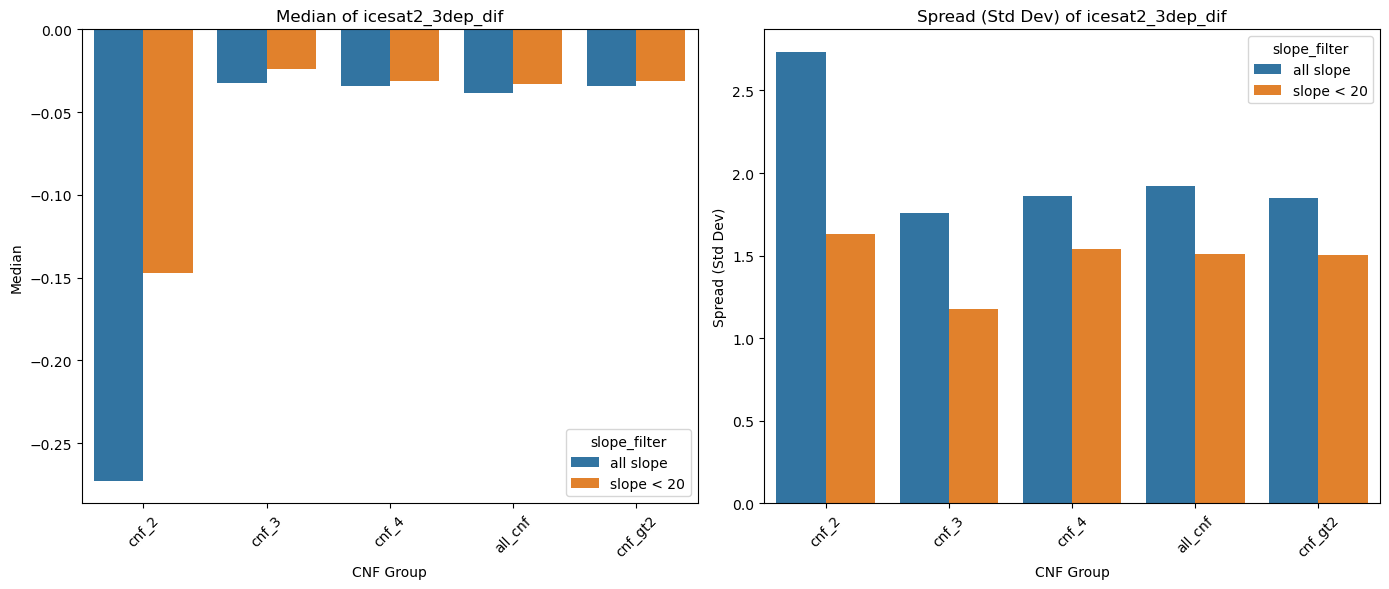

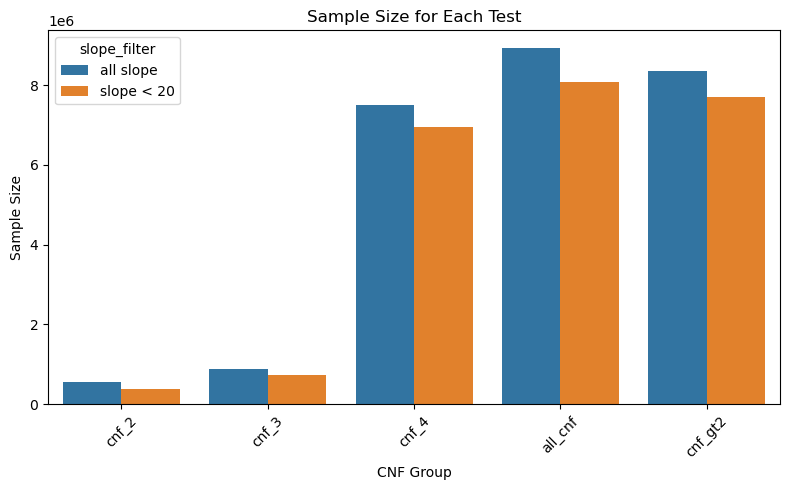

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to DataFrame if not already
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'test'})

# Split test names for plotting
results_df['slope_filter'] = results_df['test'].apply(lambda x: 'slope < 20' if 'slope_lt20' in x else 'all slope')
results_df['cnf_group'] = results_df['test'].str.replace('_slope_lt20','').str.replace('_all_slope','')

# Plot median and spread for each test
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=results_df, x='cnf_group', y='median', hue='slope_filter', ax=axes[0])
axes[0].set_title('Median of icesat2_3dep_dif')
axes[0].set_ylabel('Median')
axes[0].set_xlabel('CNF Group')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=results_df, x='cnf_group', y='spread', hue='slope_filter', ax=axes[1])
axes[1].set_title('Spread (Std Dev) of icesat2_3dep_dif')
axes[1].set_ylabel('Spread (Std Dev)')
axes[1].set_xlabel('CNF Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot sample size
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='cnf_group', y='sample_size', hue='slope_filter')
plt.title('Sample Size for Each Test')
plt.ylabel('Sample Size')
plt.xlabel('CNF Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### test the accuracy of the attributes David mentioned:

In [66]:
def download_icesat2(region, start_date, end_date):

    # Initialization
    #sliderule.init("sliderule-blue", verbose=True)
    icesat2.init("slideruleearth.io", verbose=True)

    # Parameters
    parms = {
        "poly": region,
        "srt": icesat2.SRT_LAND,
        #"cnf": icesat2.CNF_SURFACE_LOW, #As of 1/28/2026 David Shean recommends sticking with the default, to keep as much data as possible
        "atl08_class": "atl08_ground",
        "ats": 10.0,
        "cnt": 10,
        "len": 40.0,
        "res": 20.0,
        #"fit": {"maxi": 10}, #As of 1/28/2026 David Shean recommends sticking with the default maxi, which is 5
        "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
        "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "slope_aspect":True, "force_single_sample":True}},
        't0': start_date,
        't1': end_date
    }

    # Latch Start Time
    perf_start = time.perf_counter()

    # Request ATL06 Data
    gdf = icesat2.atl06p(parms) #, resources=["ATL03_20210309052953_11491002_006_01.h5"])

    # Latch Stop Time
    perf_stop = time.perf_counter()

    # Display Statistics
    perf_duration = perf_stop - perf_start
    print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
    print("Reference Ground Tracks: {}".format(gdf["rgt"].unique()))
    print("Cycles: {}".format(gdf["cycle"].unique()))
    print("Received {} elevations".format(gdf.shape[0]))

    return gdf

In [ ]:
south_sierras_2020_atl06 = download_icesat2(south_region, '2020-07-30T08:00:00Z', '2020-08-30T08:00:00Z')

Completed in 33.391 seconds of wall-clock time
Reference Ground Tracks: [ 562  623  646  707  768 1004]
Cycles: [8]
Received 360960 elevations


In [80]:
south_sierras_2020_atl06.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Download southern sierra for the three years and combine

In [72]:
# Area of Interest
south_region = [
    {"lon": -120.2, "lat": 34.818611},
    {"lon": -117.862654, "lat": 34.818611},
    {"lon": -117.862654, "lat": 37.5},
    {"lon": -120.2, "lat": 37.5},
    {"lon": -120.2, "lat": 34.818611}
]

In [30]:
south_sierras_2020_atl06['icesat2_3dep_dif'] = south_sierras_2020_atl06['h_mean'] - south_sierras_2020_atl06['3dep.value']

In [31]:
import numpy as np
import pandas as pd

def summarize_stats(df, col='icesat2_3dep_dif'):
    return {
        'median': np.median(df[col]),
        'spread': np.std(df[col]),
        'sample_size': len(df[col])
    }

# Define bin edges for each attribute
dh_fit_dx_bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, np.inf]
h_sigma_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, np.inf]
rms_misfit_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, np.inf]

results_bins = {}

# dh_fit_dx bins
for i in range(len(dh_fit_dx_bins)-1):
    lower, upper = dh_fit_dx_bins[i], dh_fit_dx_bins[i+1]
    mask = (south_sierras_2020_atl06['dh_fit_dx'] >= lower) & (south_sierras_2020_atl06['dh_fit_dx'] < upper)
    key = f'dh_fit_dx_{lower}_{upper}'
    results_bins[key] = summarize_stats(south_sierras_2020_atl06[mask])

# h_sigma bins
for i in range(len(h_sigma_bins)-1):
    lower, upper = h_sigma_bins[i], h_sigma_bins[i+1]
    mask = (south_sierras_2020_atl06['h_sigma'] >= lower) & (south_sierras_2020_atl06['h_sigma'] < upper)
    key = f'h_sigma_{lower}_{upper}'
    results_bins[key] = summarize_stats(south_sierras_2020_atl06[mask])

# rms_misfit bins
for i in range(len(rms_misfit_bins)-1):
    lower, upper = rms_misfit_bins[i], rms_misfit_bins[i+1]
    mask = (south_sierras_2020_atl06['rms_misfit'] >= lower) & (south_sierras_2020_atl06['rms_misfit'] < upper)
    key = f'rms_misfit_{lower}_{upper}'
    results_bins[key] = summarize_stats(south_sierras_2020_atl06[mask])

# Display results
pd.DataFrame(results_bins).T

,median,spread,sample_size
dh_fit_dx_0_0.05,-0.019428,1.173650,106776.0
dh_fit_dx_0.05_0.1,-0.316279,1.787746,17575.0
dh_fit_dx_0.1_0.15,-0.500726,2.203768,11271.0
dh_fit_dx_0.15_0.2,-0.706764,2.564043,8486.0
dh_fit_dx_0.2_0.25,-0.882108,2.748154,6919.0
dh_fit_dx_0.25_0.3,-1.040043,3.005377,5635.0
dh_fit_dx_0.3_0.35,-1.236048,3.118580,4694.0
dh_fit_dx_0.35_0.4,-1.406241,3.249146,4058.0
dh_fit_dx_0.4_0.45,-1.543087,3.391462,3138.0
dh_fit_dx_0.45_0.5,-1.941915,3.465980,2436.0


/opt/homebrew/Caskroom/miniforge/base/envs/sliderule_env/lib/python3.13/site-packages/matplotlib/axes/_axes.py:2624: RuntimeWarning: invalid value encountered in subtract
  left = x - width / 2


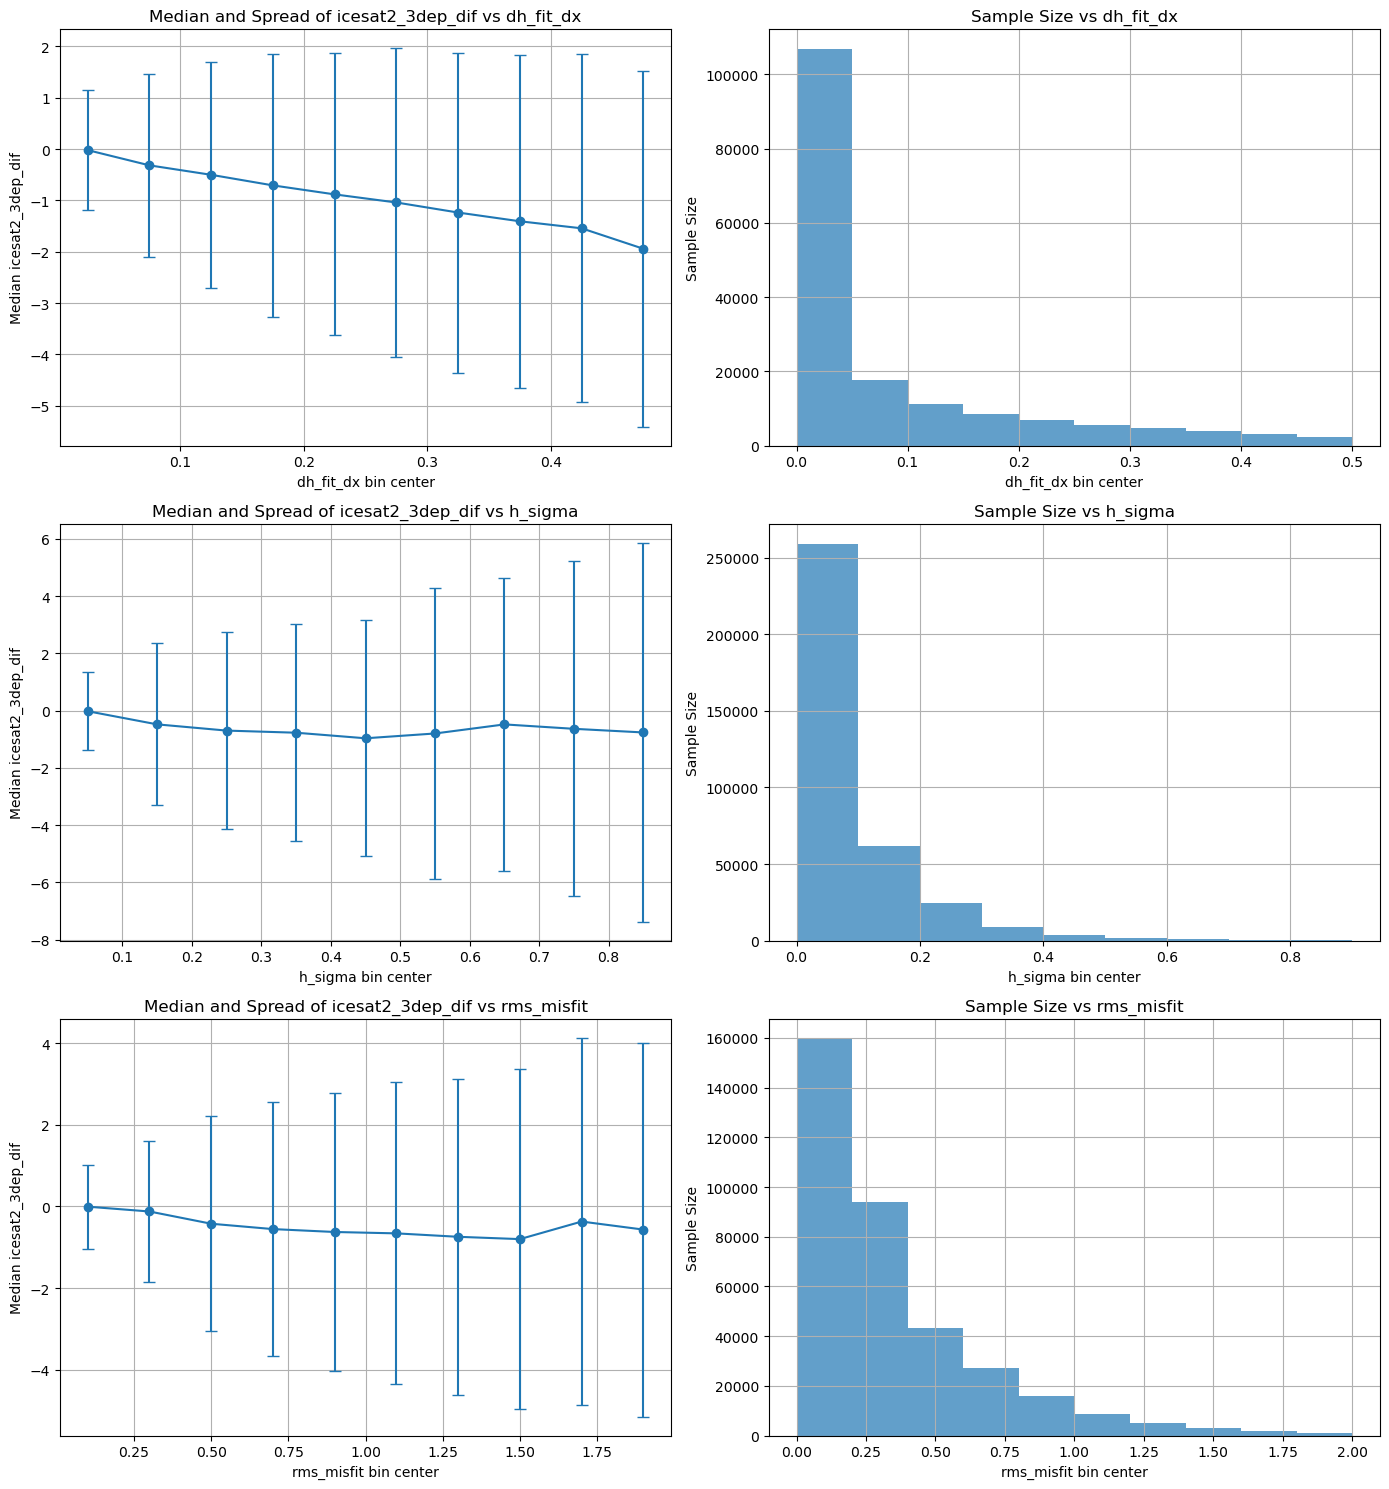

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results_bins to DataFrame for plotting
results_df = pd.DataFrame(results_bins).T.reset_index().rename(columns={'index': 'bin'})

# Extract variable and bin range for plotting
def parse_bin_info(bin_str):
    if bin_str.startswith('dh_fit_dx'):
        var = 'dh_fit_dx'
    elif bin_str.startswith('h_sigma'):
        var = 'h_sigma'
    elif bin_str.startswith('rms_misfit'):
        var = 'rms_misfit'
    else:
        var = 'unknown'
    parts = bin_str.split('_')
    lower = float(parts[-2])
    upper = float(parts[-1])
    return var, lower, upper

results_df[['variable', 'lower', 'upper']] = results_df['bin'].apply(lambda x: pd.Series(parse_bin_info(x)))

# Combined subplots for all metrics
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for i, var in enumerate(['dh_fit_dx', 'h_sigma', 'rms_misfit']):
    subset = results_df[results_df['variable'] == var]
    # Median and spread
    axes[i, 0].errorbar(x=(subset['lower']+subset['upper'])/2, y=subset['median'], yerr=subset['spread'], fmt='o-', capsize=4)
    axes[i, 0].set_title(f'Median and Spread of icesat2_3dep_dif vs {var}')
    axes[i, 0].set_xlabel(f'{var} bin center')
    axes[i, 0].set_ylabel('Median icesat2_3dep_dif')
    axes[i, 0].grid(True)
    # Sample size
    axes[i, 1].bar((subset['lower']+subset['upper'])/2, subset['sample_size'], width=(subset['upper']-subset['lower']), align='center', alpha=0.7)
    axes[i, 1].set_title(f'Sample Size vs {var}')
    axes[i, 1].set_xlabel(f'{var} bin center')
    axes[i, 1].set_ylabel('Sample Size')
    axes[i, 1].grid(True)
plt.tight_layout()
plt.show()

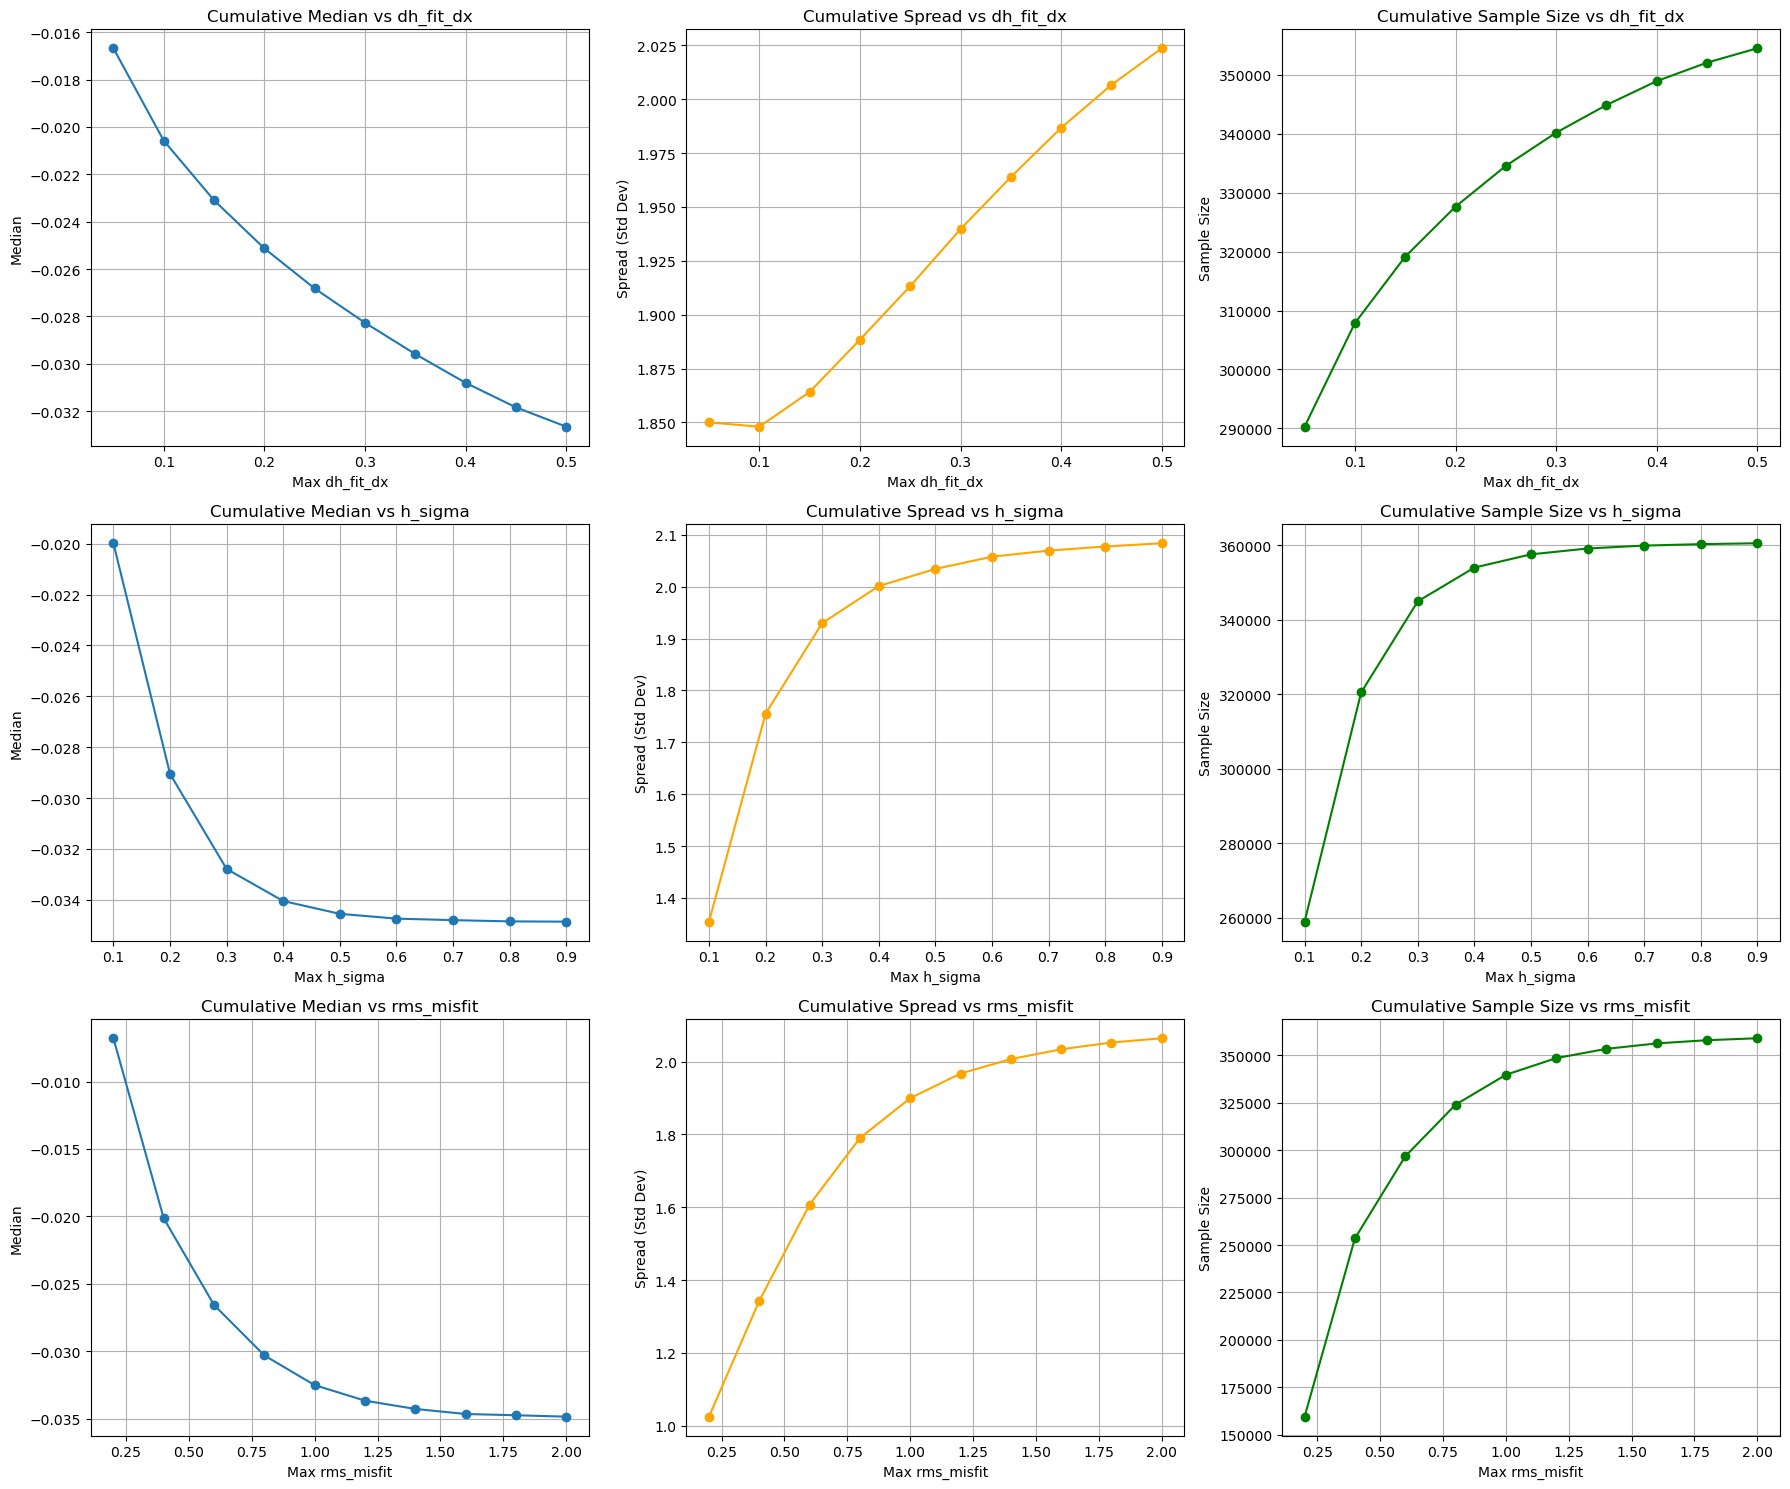

In [57]:
# Cumulative metrics for increasing attribute bin thresholds
import numpy as np
import matplotlib.pyplot as plt

# Define bin edges for each attribute (already defined above)
# dh_fit_dx_bins, h_sigma_bins, rms_misfit_bins

def cumulative_metrics(attr, bins, df):
    medians, spreads, sample_sizes, thresholds = [], [], [], []
    for upper in bins[1:]:
        mask = df[attr] < upper
        stats = summarize_stats(df[mask])
        medians.append(stats['median'])
        spreads.append(stats['spread'])
        sample_sizes.append(stats['sample_size'])
        thresholds.append(upper)
    return thresholds, medians, spreads, sample_sizes

attributes = [ ('dh_fit_dx', dh_fit_dx_bins), ('h_sigma', h_sigma_bins), ('rms_misfit', rms_misfit_bins) ]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for i, (attr, bins) in enumerate(attributes):
    thresholds, medians, spreads, sample_sizes = cumulative_metrics(attr, bins, south_sierras_2020_atl06)
    axes[i,0].plot(thresholds, medians, marker='o')
    axes[i,0].set_title(f'Cumulative Median vs {attr}')
    axes[i,0].set_xlabel(f'Max {attr}')
    axes[i,0].set_ylabel('Median')
    axes[i,0].grid(True)
    axes[i,1].plot(thresholds, spreads, marker='o', color='orange')
    axes[i,1].set_title(f'Cumulative Spread vs {attr}')
    axes[i,1].set_xlabel(f'Max {attr}')
    axes[i,1].set_ylabel('Spread (Std Dev)')
    axes[i,1].grid(True)
    axes[i,2].plot(thresholds, sample_sizes, marker='o', color='green')
    axes[i,2].set_title(f'Cumulative Sample Size vs {attr}')
    axes[i,2].set_xlabel(f'Max {attr}')
    axes[i,2].set_ylabel('Sample Size')
    axes[i,2].grid(True)
plt.tight_layout()
plt.show()

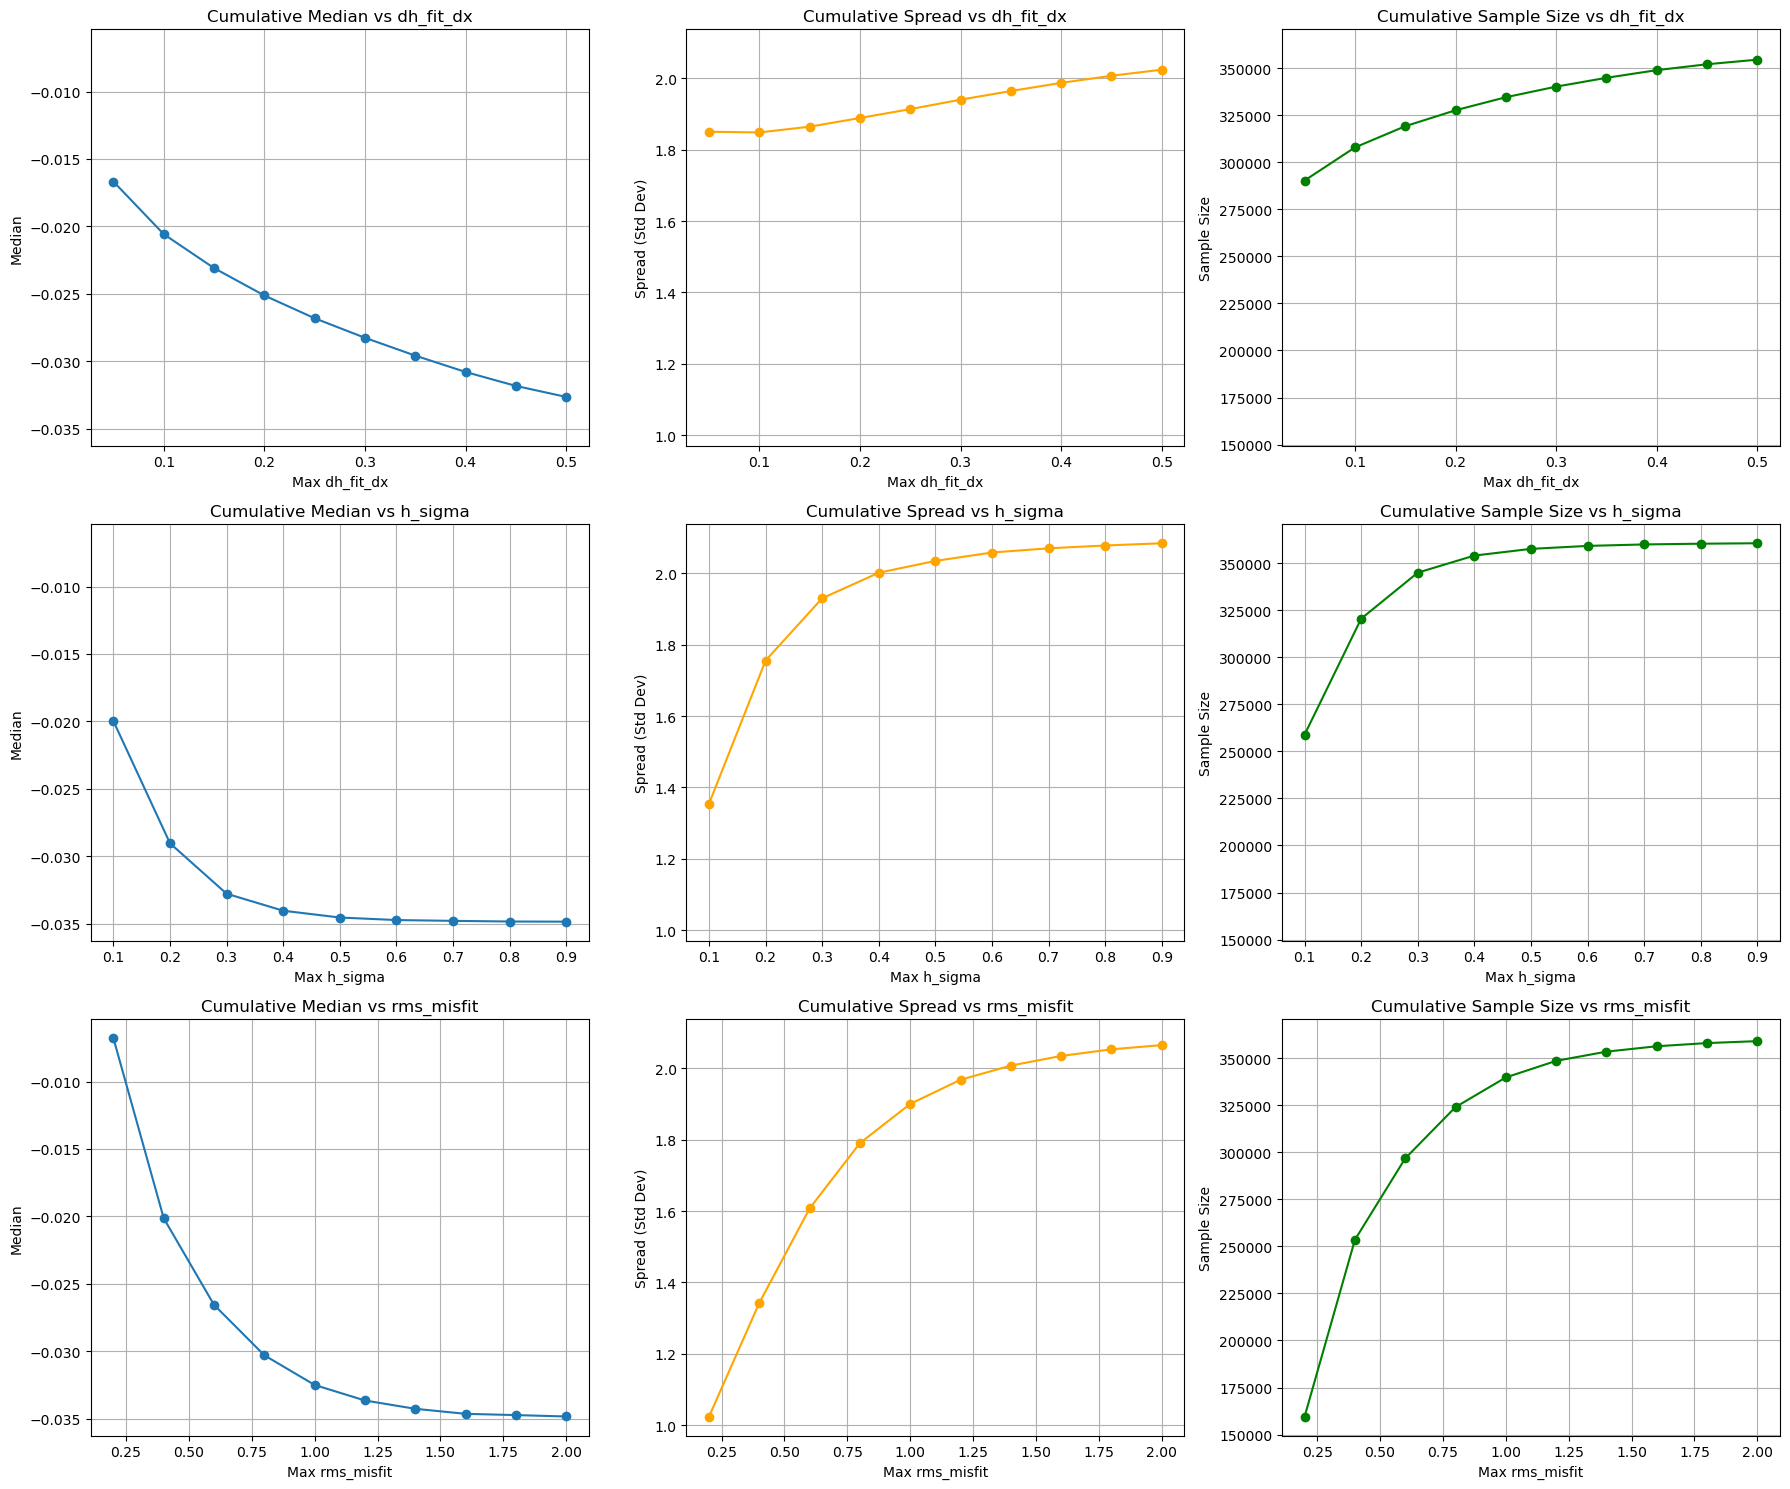

In [58]:
# Cumulative metrics for increasing attribute bin thresholds with shared y-axes among columns
import numpy as np
import matplotlib.pyplot as plt

# Define bin edges for each attribute (already defined above)
# dh_fit_dx_bins, h_sigma_bins, rms_misfit_bins

def cumulative_metrics(attr, bins, df):
    medians, spreads, sample_sizes, thresholds = [], [], [], []
    for upper in bins[1:]:
        mask = df[attr] < upper
        stats = summarize_stats(df[mask])
        medians.append(stats['median'])
        spreads.append(stats['spread'])
        sample_sizes.append(stats['sample_size'])
        thresholds.append(upper)
    return thresholds, medians, spreads, sample_sizes

attributes = [ ('dh_fit_dx', dh_fit_dx_bins), ('h_sigma', h_sigma_bins), ('rms_misfit', rms_misfit_bins) ]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharey='col')
for i, (attr, bins) in enumerate(attributes):
    thresholds, medians, spreads, sample_sizes = cumulative_metrics(attr, bins, south_sierras_2020_atl06)
    axes[i,0].plot(thresholds, medians, marker='o')
    axes[i,0].set_title(f'Cumulative Median vs {attr}')
    axes[i,0].set_xlabel(f'Max {attr}')
    axes[i,0].set_ylabel('Median')
    axes[i,0].grid(True)
    axes[i,1].plot(thresholds, spreads, marker='o', color='orange')
    axes[i,1].set_title(f'Cumulative Spread vs {attr}')
    axes[i,1].set_xlabel(f'Max {attr}')
    axes[i,1].set_ylabel('Spread (Std Dev)')
    axes[i,1].grid(True)
    axes[i,2].plot(thresholds, sample_sizes, marker='o', color='green')
    axes[i,2].set_title(f'Cumulative Sample Size vs {attr}')
    axes[i,2].set_xlabel(f'Max {attr}')
    axes[i,2].set_ylabel('Sample Size')
    axes[i,2].grid(True)
plt.tight_layout()
plt.show()

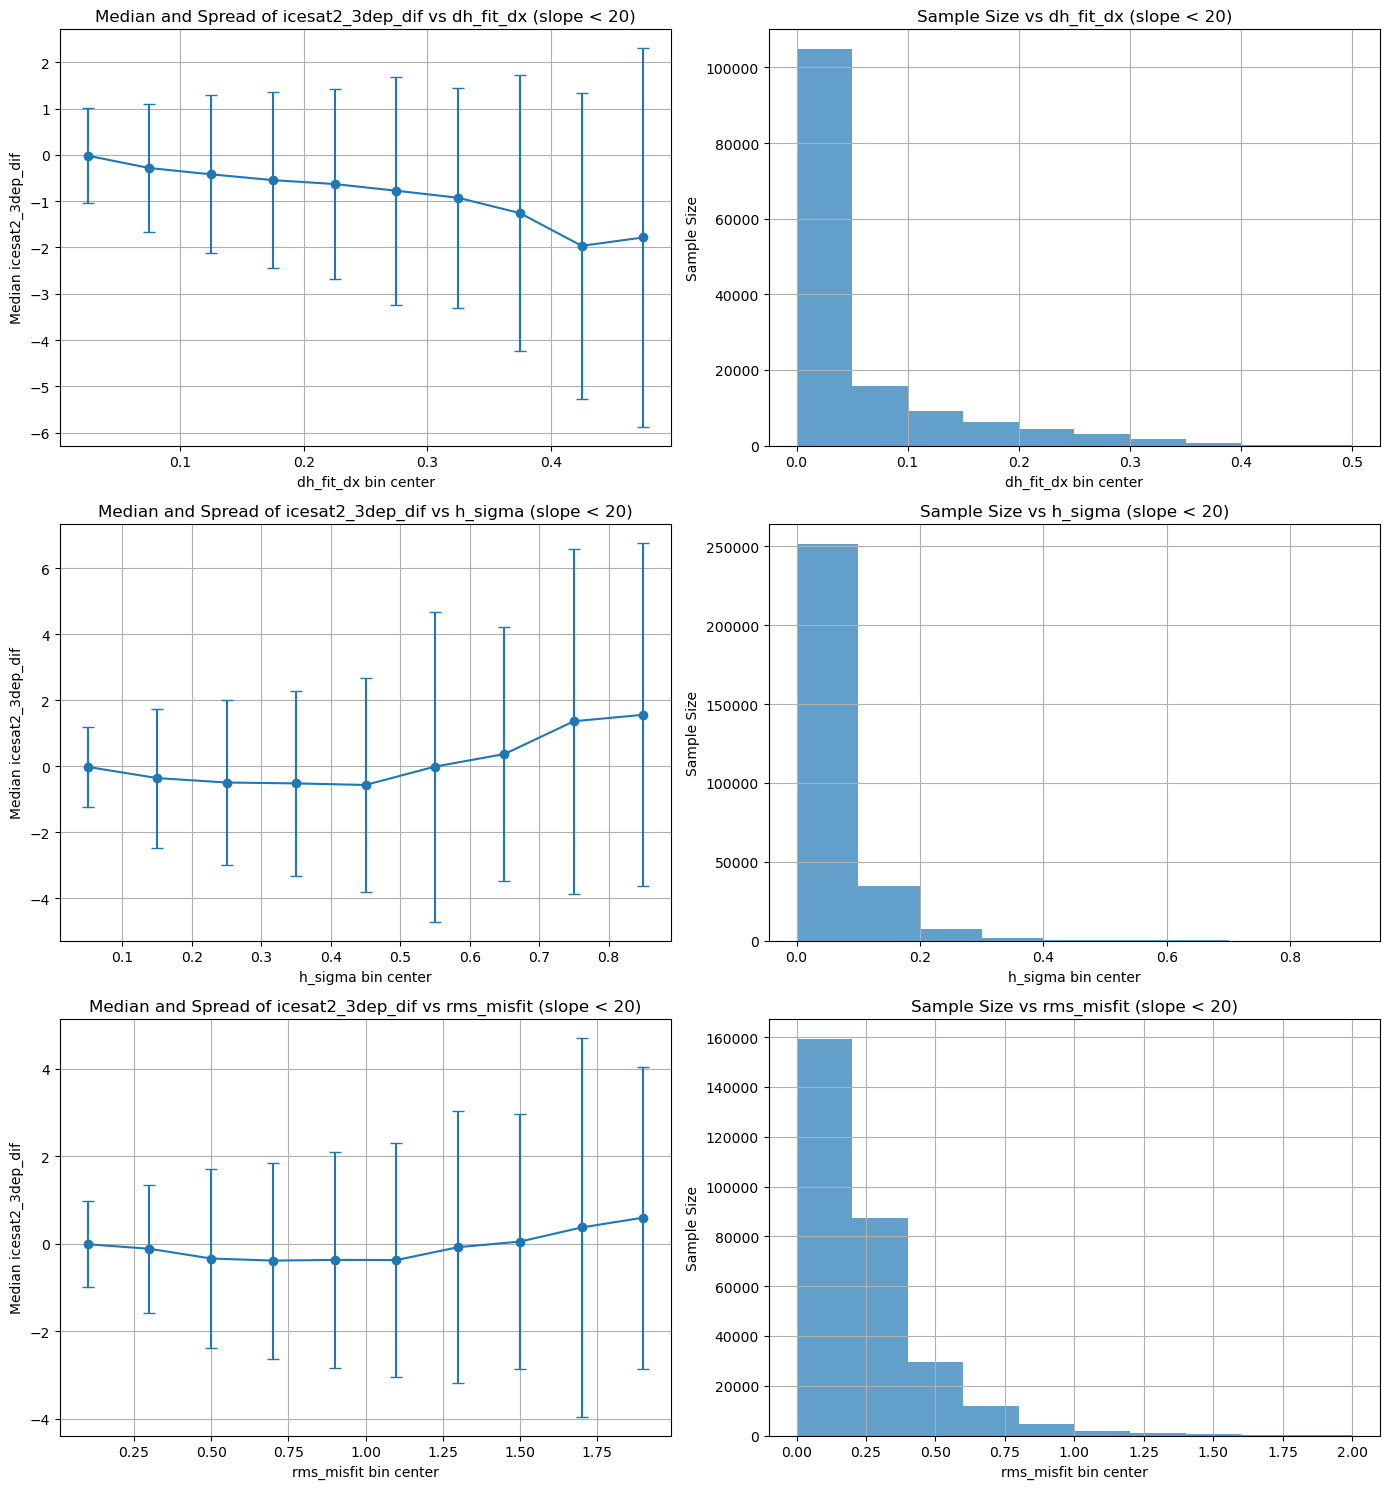

In [54]:
# Combined subplots for all metrics (slope < 20)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for i, var in enumerate(['dh_fit_dx', 'h_sigma', 'rms_misfit']):
    subset = results_bins_df_slope_lt20[results_bins_df_slope_lt20['variable'] == var]
    # Median and spread
    axes[i, 0].errorbar(x=(subset['lower']+subset['upper'])/2, y=subset['median'], yerr=subset['spread'], fmt='o-', capsize=4)
    axes[i, 0].set_title(f'Median and Spread of icesat2_3dep_dif vs {var} (slope < 20)')
    axes[i, 0].set_xlabel(f'{var} bin center')
    axes[i, 0].set_ylabel('Median icesat2_3dep_dif')
    axes[i, 0].grid(True)
    # Sample size
    axes[i, 1].bar((subset['lower']+subset['upper'])/2, subset['sample_size'], width=(subset['upper']-subset['lower']), align='center', alpha=0.7)
    axes[i, 1].set_title(f'Sample Size vs {var} (slope < 20)')
    axes[i, 1].set_xlabel(f'{var} bin center')
    axes[i, 1].set_ylabel('Sample Size')
    axes[i, 1].grid(True)
plt.tight_layout()
plt.show()

In [44]:
# Calculate metrics for data with lowest value of all 3 attributes (dh_fit_dx, h_sigma, rms_misfit)
lowest_mask = (south_sierras_2020_atl06['dh_fit_dx'] < 0.05) & \
              (south_sierras_2020_atl06['h_sigma'] < 0.1) & \
              (south_sierras_2020_atl06['rms_misfit'] < 0.2)
lowest_stats = summarize_stats(south_sierras_2020_atl06[lowest_mask])
print('Metrics for lowest bin of all 3 attributes:')
print(lowest_stats)

# Also calculate for slope < 20
lowest_mask_slope_lt20 = lowest_mask & (south_sierras_2020_atl06['3dep.slope'] < 20)
lowest_stats_slope_lt20 = summarize_stats(south_sierras_2020_atl06[lowest_mask_slope_lt20])
print('Metrics for lowest bin of all 3 attributes with slope < 20:')
print(lowest_stats_slope_lt20)

Metrics for lowest bin of all 3 attributes:
{'median': np.float64(-0.006380897082181036), 'spread': np.float64(1.0179153621881645), 'sample_size': 157776}
Metrics for lowest bin of all 3 attributes with slope < 20:
{'median': np.float64(-0.006271063799431431), 'spread': np.float64(0.9859449714082067), 'sample_size': 157486}


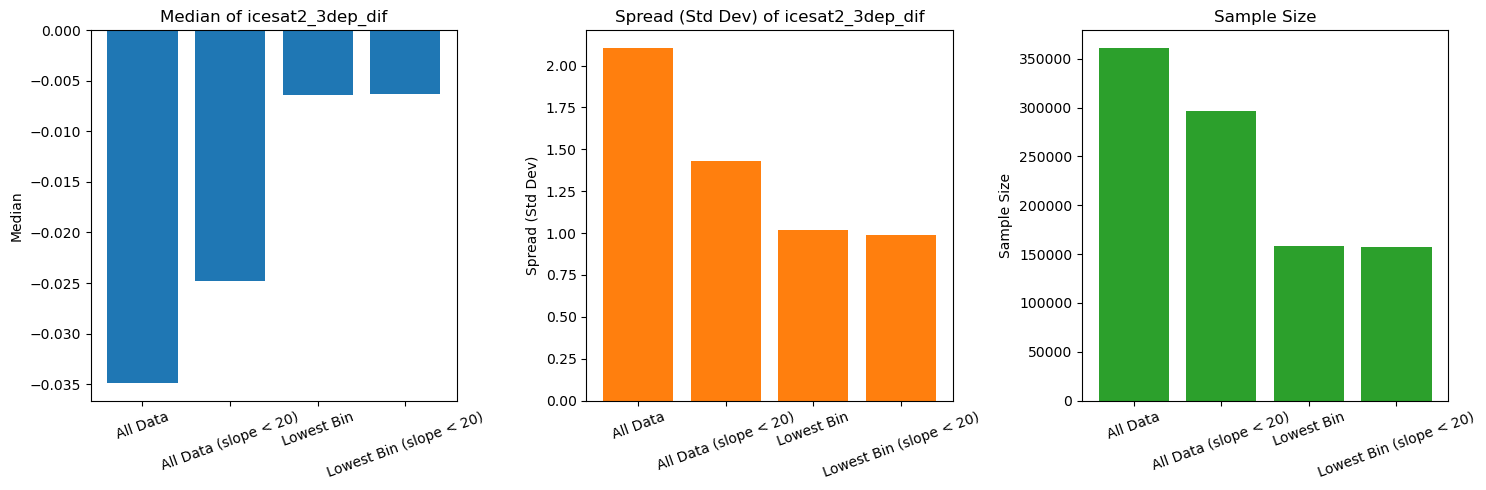

In [55]:
import matplotlib.pyplot as plt

# Summarize metrics for all/lowest bins, all data and slope < 20
metrics_labels = ['All Data', 'All Data (slope < 20)', 'Lowest Bin', 'Lowest Bin (slope < 20)']
medians = [all_stats['median'], all_stats_slope_lt20['median'], lowest_stats['median'], lowest_stats_slope_lt20['median']]
spreads = [all_stats['spread'], all_stats_slope_lt20['spread'], lowest_stats['spread'], lowest_stats_slope_lt20['spread']]
sample_sizes = [all_stats['sample_size'], all_stats_slope_lt20['sample_size'], lowest_stats['sample_size'], lowest_stats_slope_lt20['sample_size']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(metrics_labels, medians, color='tab:blue')
axes[0].set_title('Median of icesat2_3dep_dif')
axes[0].set_ylabel('Median')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(metrics_labels, spreads, color='tab:orange')
axes[1].set_title('Spread (Std Dev) of icesat2_3dep_dif')
axes[1].set_ylabel('Spread (Std Dev)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(metrics_labels, sample_sizes, color='tab:green')
axes[2].set_title('Sample Size')
axes[2].set_ylabel('Sample Size')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [34]:
# Calculate metrics for all data in south_sierras_2020_atl06
all_stats = summarize_stats(south_sierras_2020_atl06)
print('Metrics for all data:')
print(all_stats)

Metrics for all data:
{'median': np.float64(-0.034886922134049314), 'spread': np.float64(2.104912204172924), 'sample_size': 360960}


In [42]:
# Calculate metrics for all data with slope < 20
slope_mask = south_sierras_2020_atl06['3dep.slope'] < 20
all_stats_slope_lt20 = summarize_stats(south_sierras_2020_atl06[slope_mask])
print('Metrics for all data with slope < 20:')
print(all_stats_slope_lt20)

# Calculate metrics for lowest bin of all 3 attributes with slope < 20
lowest_mask_slope_lt20 = lowest_mask & slope_mask
lowest_stats_slope_lt20 = summarize_stats(south_sierras_2020_atl06[lowest_mask_slope_lt20])
print('Metrics for lowest bin of all 3 attributes with slope < 20:')
print(lowest_stats_slope_lt20)

Metrics for all data with slope < 20:
{'median': np.float64(-0.024771410237615754), 'spread': np.float64(1.430386229137219), 'sample_size': 296745}
Metrics for lowest bin of all 3 attributes with slope < 20:
{'median': np.float64(-0.006271063799431431), 'spread': np.float64(0.9859449714082067), 'sample_size': 157486}


In [37]:
((360960 - 157776) / 360960) * 100

56.28989361702128

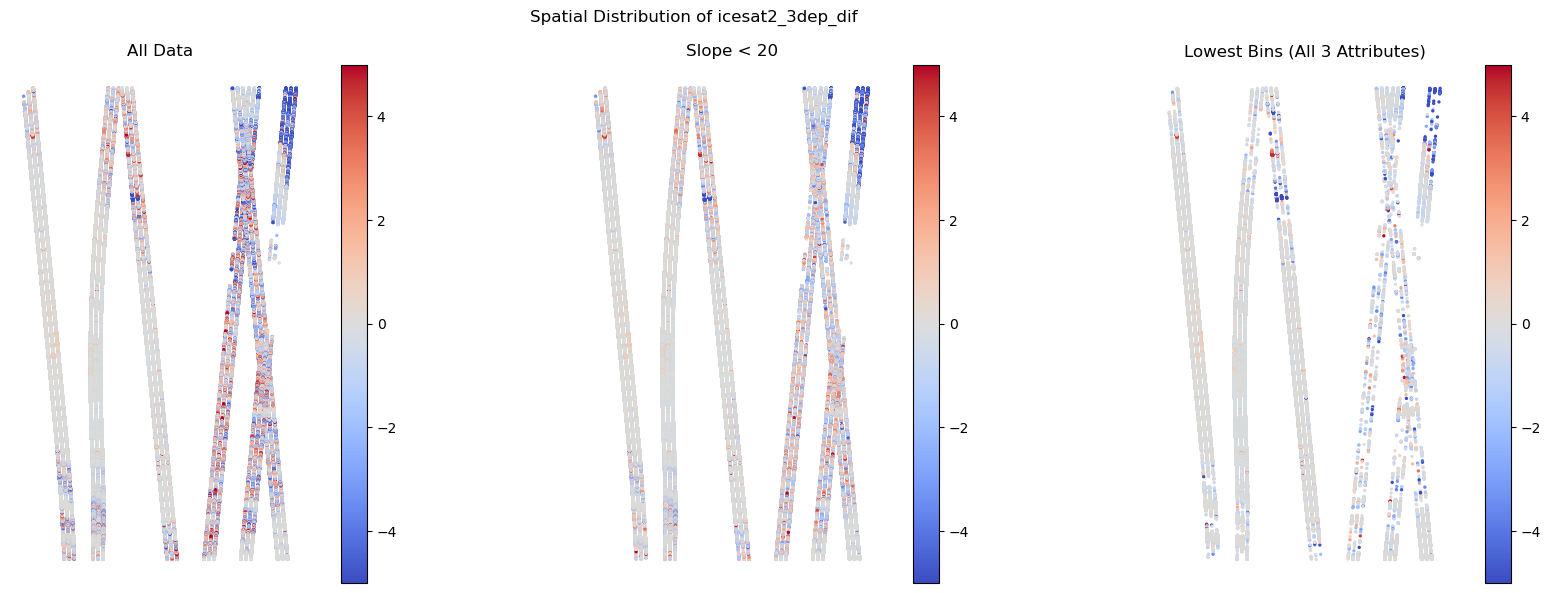

In [63]:
import matplotlib.pyplot as plt
# Define masks
slope_mask = south_sierras_2020_atl06['3dep.slope'] < 20
lowest_mask = (
    (south_sierras_2020_atl06['dh_fit_dx'] < 0.05) &
    (south_sierras_2020_atl06['h_sigma'] < 0.1) &
    (south_sierras_2020_atl06['rms_misfit'] < 0.2)
)

vmin=-5
vmax=5

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# All data
south_sierras_2020_atl06.plot(column='icesat2_3dep_dif', ax=axes[0], legend=True, cmap='coolwarm', markersize=2, vmin=vmin, vmax=vmax)
axes[0].set_title('All Data')
# Slope < 20
south_sierras_2020_atl06[slope_mask].plot(column='icesat2_3dep_dif', ax=axes[1], legend=True, cmap='coolwarm', markersize=2, vmin=vmin, vmax=vmax)
axes[1].set_title('Slope < 20')
# Lowest bins of all 3 attributes
south_sierras_2020_atl06[lowest_mask].plot(column='icesat2_3dep_dif', ax=axes[2], legend=True, cmap='coolwarm', markersize=2, vmin=vmin, vmax=vmax)
axes[2].set_title('Lowest Bins (All 3 Attributes)')
for ax in axes:
    ax.set_axis_off()
plt.suptitle('Spatial Distribution of icesat2_3dep_dif')
plt.tight_layout()
plt.show()

In [ ]:
south_sierras_2020_atl06.plot(column='icesat2_3dep_dif')

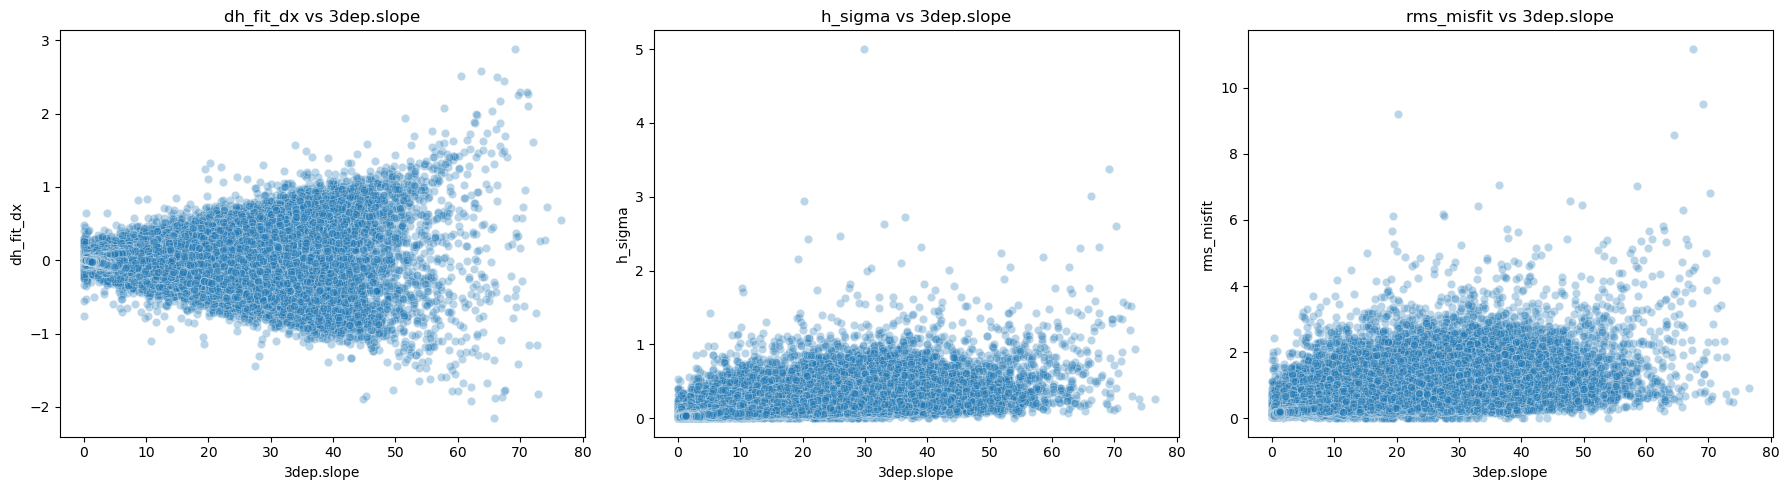

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='3dep.slope', y='dh_fit_dx', data=south_sierras_2020_atl06, alpha=0.3, ax=axes[0])
axes[0].set_title('dh_fit_dx vs 3dep.slope')
axes[0].set_xlabel('3dep.slope')
axes[0].set_ylabel('dh_fit_dx')

sns.scatterplot(x='3dep.slope', y='h_sigma', data=south_sierras_2020_atl06, alpha=0.3, ax=axes[1])
axes[1].set_title('h_sigma vs 3dep.slope')
axes[1].set_xlabel('3dep.slope')
axes[1].set_ylabel('h_sigma')

sns.scatterplot(x='3dep.slope', y='rms_misfit', data=south_sierras_2020_atl06, alpha=0.3, ax=axes[2])
axes[2].set_title('rms_misfit vs 3dep.slope')
axes[2].set_xlabel('3dep.slope')
axes[2].set_ylabel('rms_misfit')

plt.tight_layout()
plt.show()

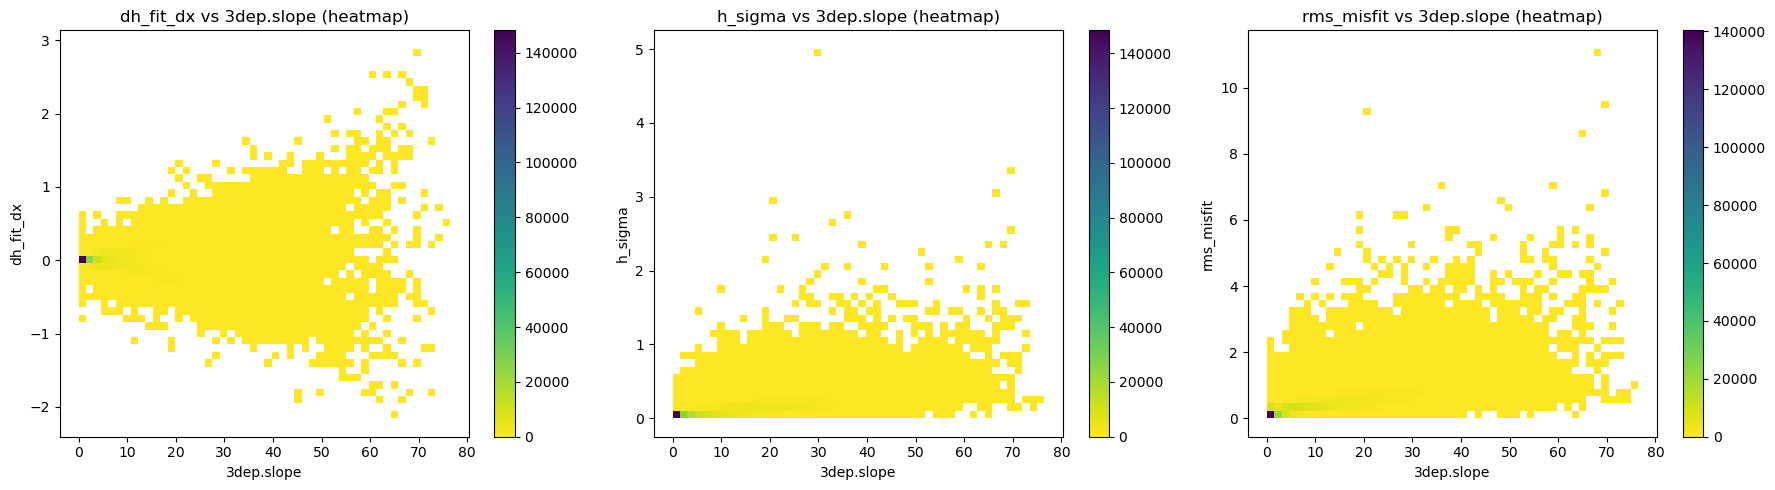

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# dh_fit_dx vs 3dep.slope
sns.histplot(data=south_sierras_2020_atl06, x='3dep.slope', y='dh_fit_dx', bins=50, pmax=0.99, cmap='viridis_r', cbar=True, ax=axes[0])
axes[0].set_title('dh_fit_dx vs 3dep.slope (heatmap)')
axes[0].set_xlabel('3dep.slope')
axes[0].set_ylabel('dh_fit_dx')

# h_sigma vs 3dep.slope
sns.histplot(data=south_sierras_2020_atl06, x='3dep.slope', y='h_sigma', bins=50, pmax=0.99, cmap='viridis_r', cbar=True, ax=axes[1])
axes[1].set_title('h_sigma vs 3dep.slope (heatmap)')
axes[1].set_xlabel('3dep.slope')
axes[1].set_ylabel('h_sigma')

# rms_misfit vs 3dep.slope
sns.histplot(data=south_sierras_2020_atl06, x='3dep.slope', y='rms_misfit', bins=50, pmax=0.99, cmap='viridis_r', cbar=True, ax=axes[2])
axes[2].set_title('rms_misfit vs 3dep.slope (heatmap)')
axes[2].set_xlabel('3dep.slope')
axes[2].set_ylabel('rms_misfit')

plt.tight_layout()
plt.show()

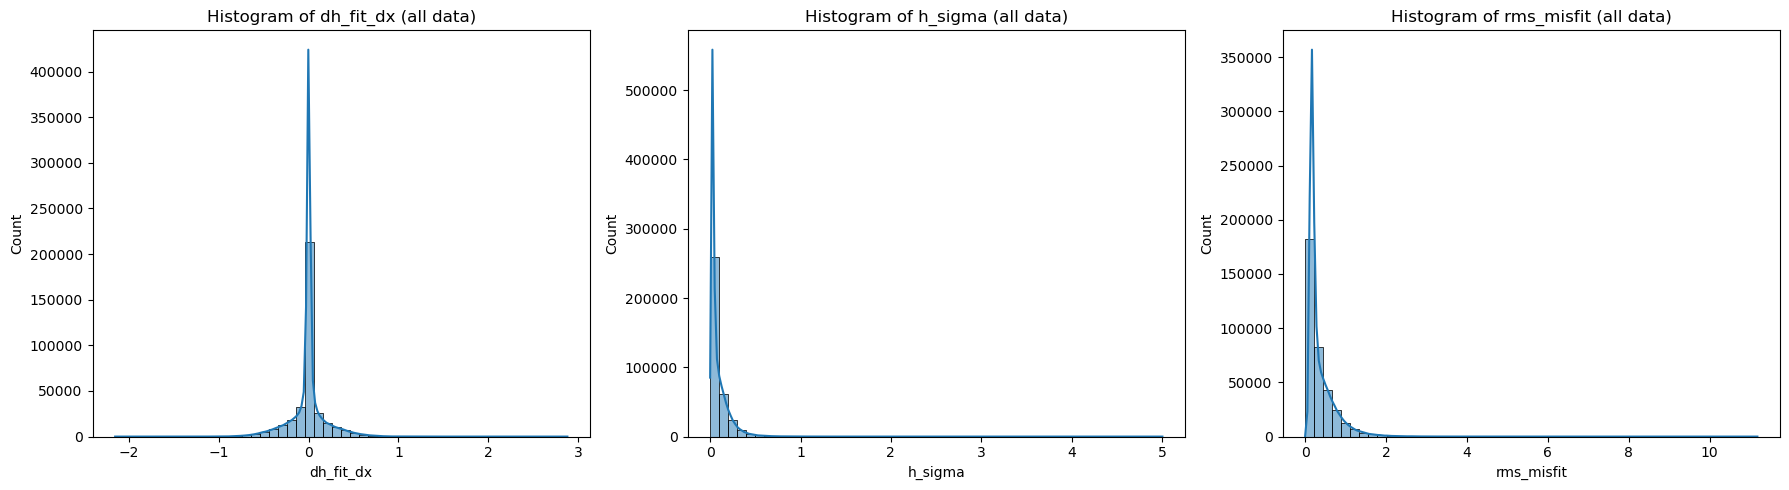

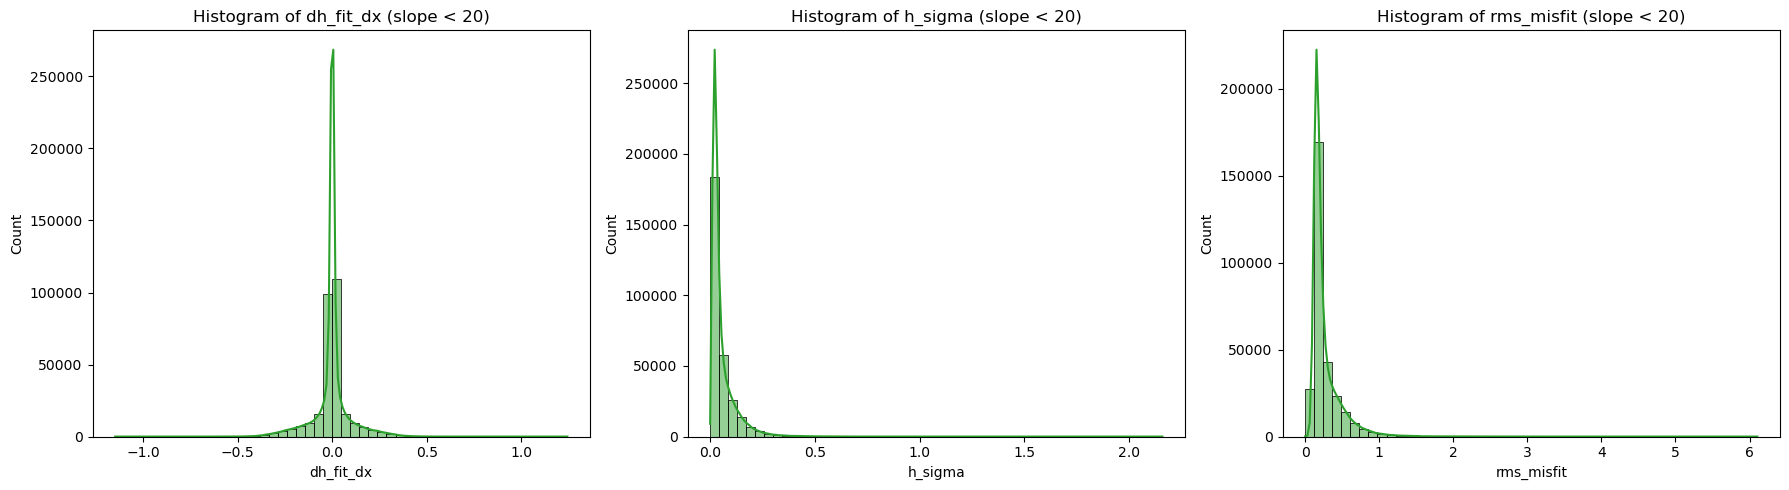

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

attributes = ['dh_fit_dx', 'h_sigma', 'rms_misfit']

# Histogram for all data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, attr in enumerate(attributes):
    sns.histplot(south_sierras_2020_atl06[attr], bins=50, kde=True, ax=axes[i], color='tab:blue')
    axes[i].set_title(f'Histogram of {attr} (all data)')
    axes[i].set_xlabel(attr)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

# Histogram for data with slope < 20
slope_mask = south_sierras_2020_atl06['3dep.slope'] < 20
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, attr in enumerate(attributes):
    sns.histplot(south_sierras_2020_atl06.loc[slope_mask, attr], bins=50, kde=True, ax=axes[i], color='tab:green')
    axes[i].set_title(f'Histogram of {attr} (slope < 20)')
    axes[i].set_xlabel(attr)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

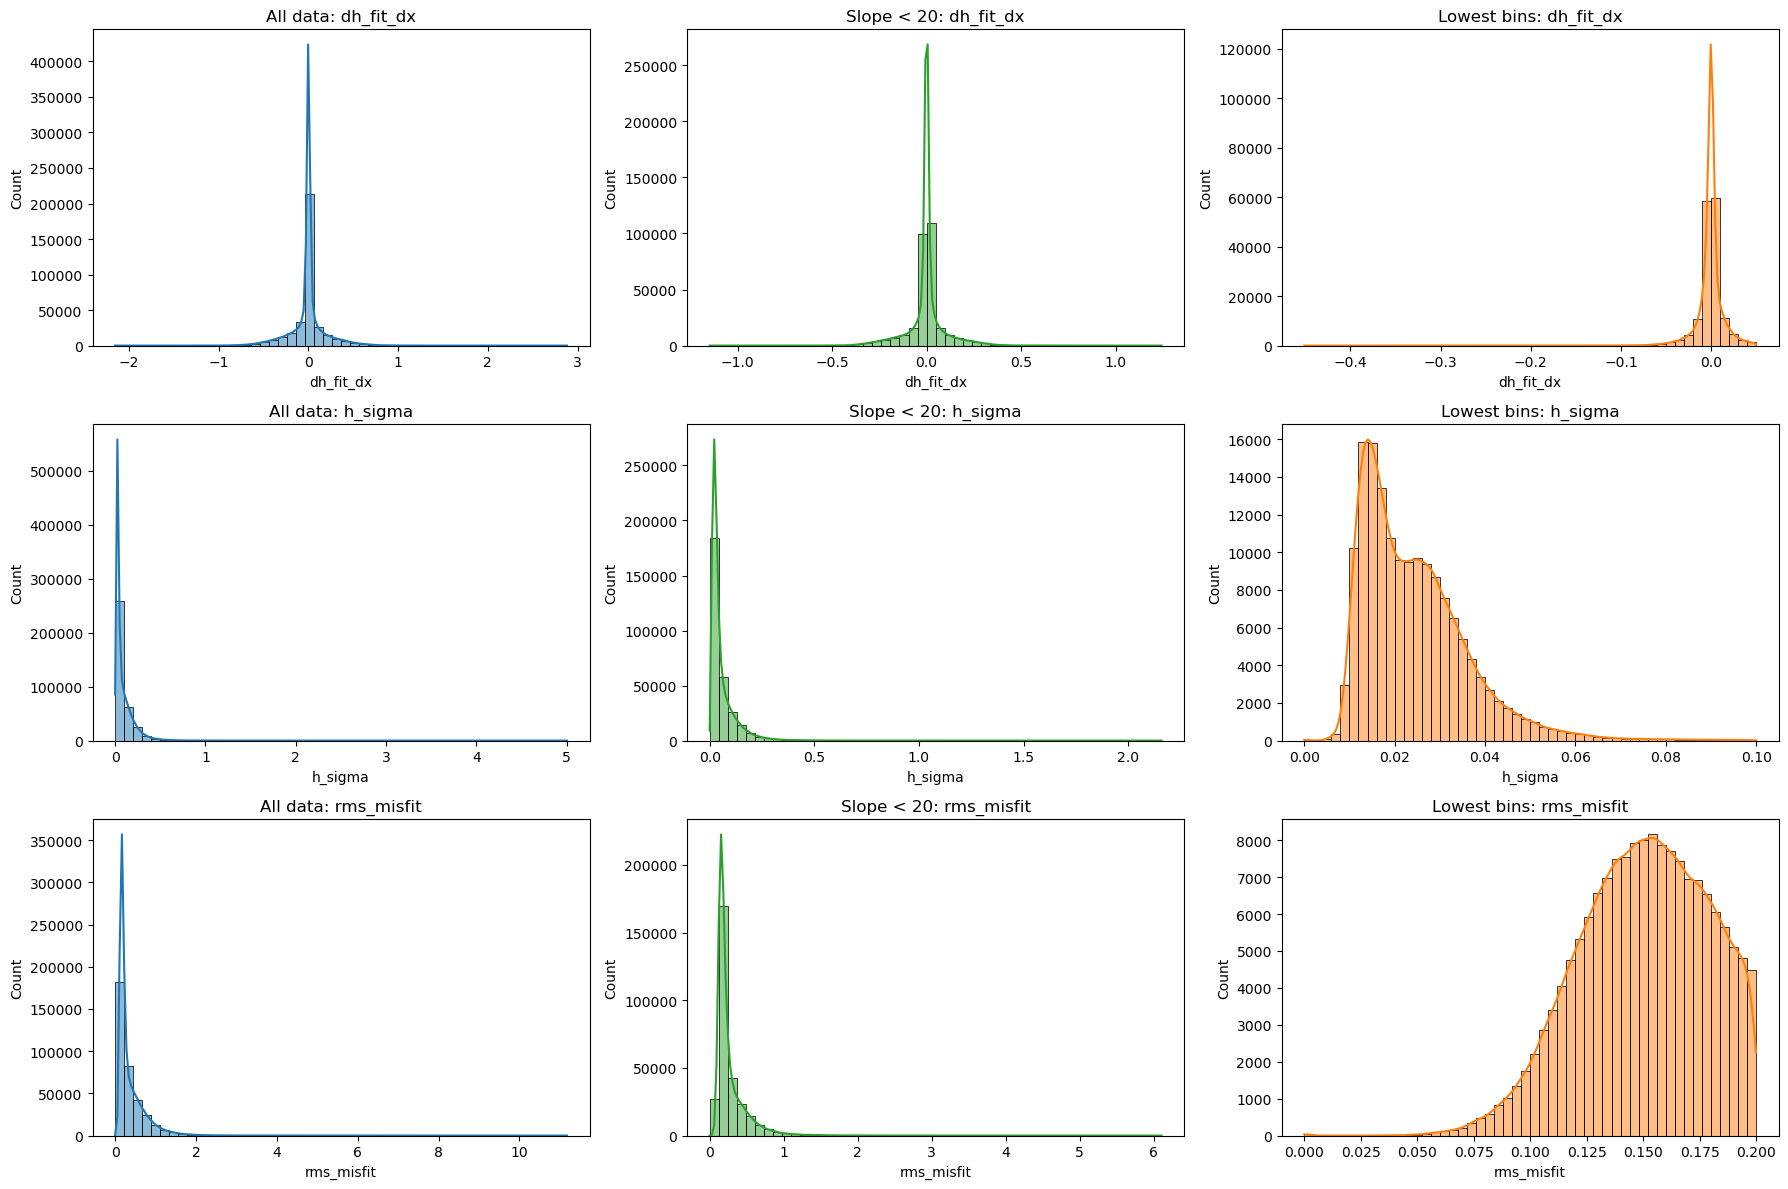

In [61]:
# Histograms for all data, slope < 20, and lowest bins of all 3 attributes
import matplotlib.pyplot as plt
import seaborn as sns

attributes = ['dh_fit_dx', 'h_sigma', 'rms_misfit']

# Define masks
slope_mask = south_sierras_2020_atl06['3dep.slope'] < 20
lowest_mask = (
    (south_sierras_2020_atl06['dh_fit_dx'] < 0.05) &
    (south_sierras_2020_atl06['h_sigma'] < 0.1) &
    (south_sierras_2020_atl06['rms_misfit'] < 0.2)
)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for i, attr in enumerate(attributes):
    # All data
    sns.histplot(south_sierras_2020_atl06[attr], bins=50, kde=True, ax=axes[i,0], color='tab:blue')
    axes[i,0].set_title(f'All data: {attr}')
    axes[i,0].set_xlabel(attr)
    axes[i,0].set_ylabel('Count')
    # Slope < 20
    sns.histplot(south_sierras_2020_atl06.loc[slope_mask, attr], bins=50, kde=True, ax=axes[i,1], color='tab:green')
    axes[i,1].set_title(f'Slope < 20: {attr}')
    axes[i,1].set_xlabel(attr)
    axes[i,1].set_ylabel('Count')
    # Lowest bins of all 3 attributes
    sns.histplot(south_sierras_2020_atl06.loc[lowest_mask, attr], bins=50, kde=True, ax=axes[i,2], color='tab:orange')
    axes[i,2].set_title(f'Lowest bins: {attr}')
    axes[i,2].set_xlabel(attr)
    axes[i,2].set_ylabel('Count')
plt.tight_layout()
plt.show()

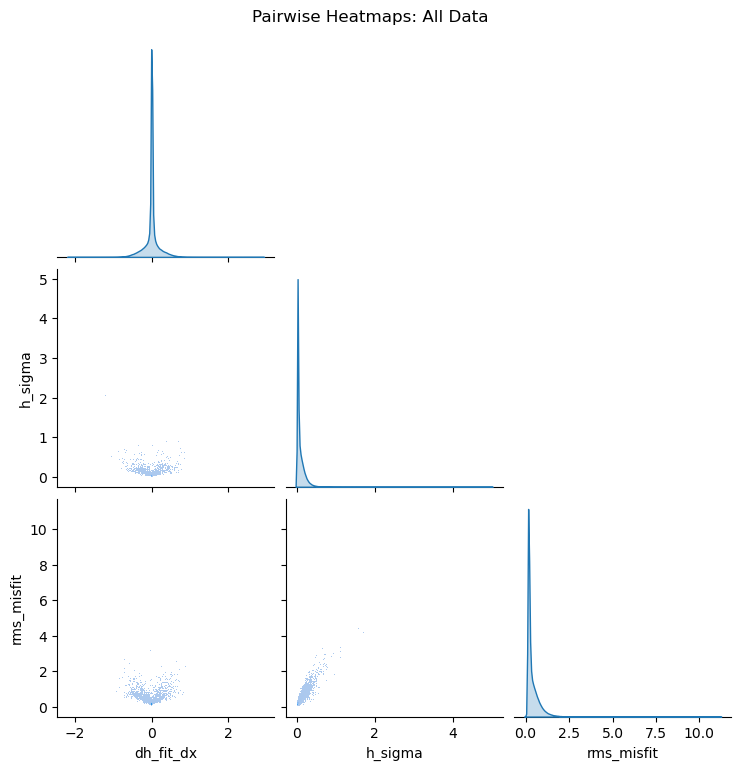

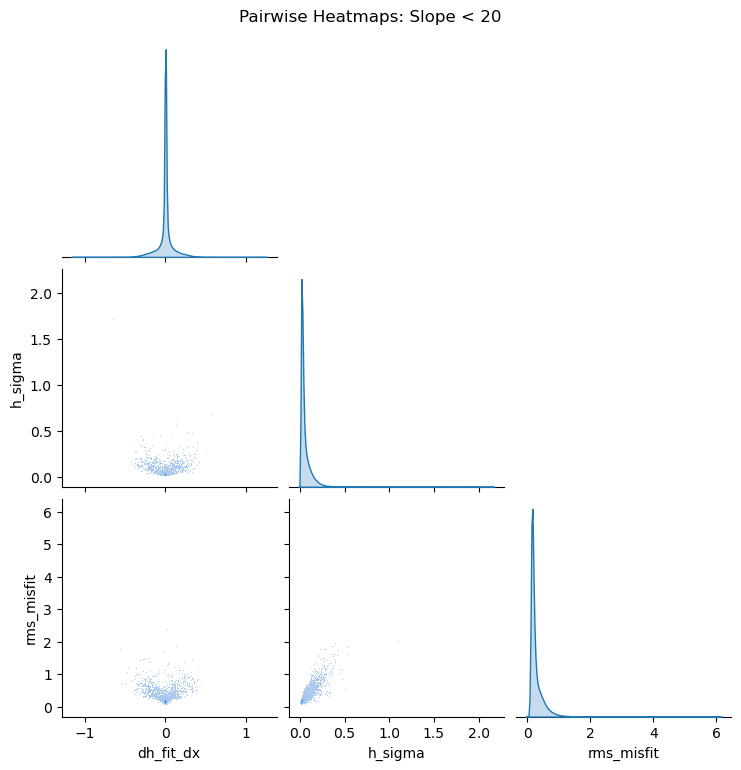

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot for all data
sns.pairplot(south_sierras_2020_atl06[['dh_fit_dx', 'h_sigma', 'rms_misfit']], kind='hist', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Heatmaps: All Data', y=1.02)
plt.show()

# Pairplot for data with slope < 20
slope_mask = south_sierras_2020_atl06['3dep.slope'] < 20
sns.pairplot(south_sierras_2020_atl06.loc[slope_mask, ['dh_fit_dx', 'h_sigma', 'rms_misfit']], kind='hist', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Heatmaps: Slope < 20', y=1.02)
plt.show()

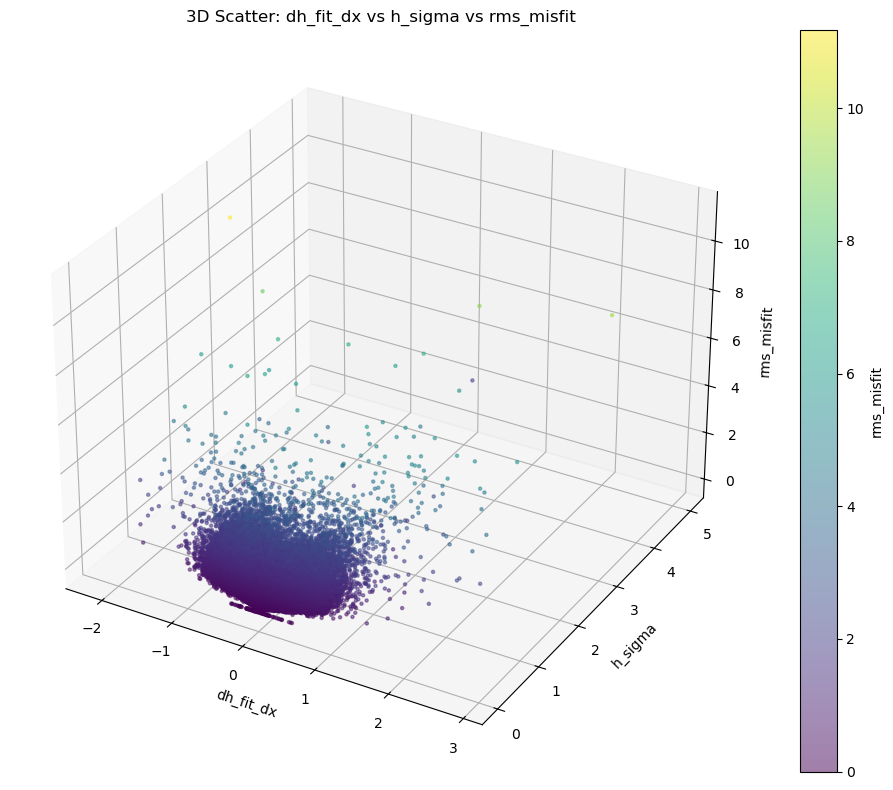

In [60]:
# 3D scatter plot of dh_fit_dx, h_sigma, and rms_misfit
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = south_sierras_2020_atl06['dh_fit_dx']
y = south_sierras_2020_atl06['h_sigma']
z = south_sierras_2020_atl06['rms_misfit']

sc = ax.scatter(x, y, z, c=z, cmap='viridis', alpha=0.5, s=5)
ax.set_xlabel('dh_fit_dx')
ax.set_ylabel('h_sigma')
ax.set_zlabel('rms_misfit')
plt.title('3D Scatter: dh_fit_dx vs h_sigma vs rms_misfit')
fig.colorbar(sc, ax=ax, label='rms_misfit')
plt.tight_layout()
plt.show()

### Download Sierra Nevada for all 3 water years using atl06 call:

In [ ]:
def download_icesat2(region, start_date, end_date):

    # Initialization
    #sliderule.init("sliderule-blue", verbose=True)
    icesat2.init("slideruleearth.io", verbose=True)

    # Parameters
    parms = {
        "poly": region,
        "srt": icesat2.SRT_LAND,
        #"cnf": icesat2.CNF_SURFACE_LOW, #As of 1/28/2026 David Shean recommends sticking with the default, to keep as much data as possible
        "atl08_class": "atl08_ground",
        "ats": 10.0,
        "cnt": 10,
        "len": 40.0,
        "res": 20.0,
        #"fit": {"maxi": 10}, #As of 1/28/2026 David Shean recommends sticking with the default maxi, which is 5
        "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
        "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "slope_aspect":True, "force_single_sample":True}},
        't0': start_date,
        't1': end_date
    }

    # Latch Start Time
    perf_start = time.perf_counter()

    # Request ATL06 Data
    gdf = icesat2.atl06p(parms) #, resources=["ATL03_20210309052953_11491002_006_01.h5"])

    # Latch Stop Time
    perf_stop = time.perf_counter()

    # Display Statistics
    perf_duration = perf_stop - perf_start
    print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
    print("Reference Ground Tracks: {}".format(gdf["rgt"].unique()))
    print("Cycles: {}".format(gdf["cycle"].unique()))
    print("Received {} elevations".format(gdf.shape[0]))

    return gdf

In [ ]:
poly_fn = '../data/misc/sierra_simplified.geojson'
region_full = sliderule.toregion(poly_fn)["poly"]

from shapely.geometry import Polygon, box
import numpy as np

# Load the original region as a GeoDataFrame
sierra_gdf = gpd.read_file(poly_fn)
sierra_geom = sierra_gdf.geometry.union_all()

# Get the bounding box of the full sierra polygon
minx, miny, maxx, maxy = sierra_geom.bounds

# Split into 4 equal latitude bands
lat_edges = np.linspace(miny, maxy, 5)  # 5 edges for 4 bands

regions = []
regions_gdf = []
for i in range(4):
    # Create a bounding box for this latitude band
    band_box = box(minx, lat_edges[i], maxx, lat_edges[i+1])
    # Clip the sierra polygon to this band
    clipped = sierra_geom.intersection(band_box)
    if not clipped.is_empty:
        # Convert to sliderule format (list of lon/lat dicts)
        if clipped.geom_type == 'Polygon':
            coords = list(clipped.exterior.coords)
        elif clipped.geom_type == 'MultiPolygon':
            # Use the largest polygon if it's a MultiPolygon
            largest = max(clipped.geoms, key=lambda g: g.area)
            coords = list(largest.exterior.coords)
        else:
            coords = []
        region_dict = [{"lon": c[0], "lat": c[1]} for c in coords]
        regions.append(region_dict)
        regions_gdf.append(gpd.GeoDataFrame(geometry=[clipped], crs=sierra_gdf.crs))

# Name the regions from south to north
region_names = ['region_1_south', 'region_2', 'region_3', 'region_4_north']
for idx, name in enumerate(region_names):
    print(f"{name}: {len(regions[idx])} vertices")

region_1_south: 369 vertices
region_2: 532 vertices
region_3: 716 vertices
region_4_north: 722 vertices


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_3086/933644180.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left')
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_3086/933644180.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


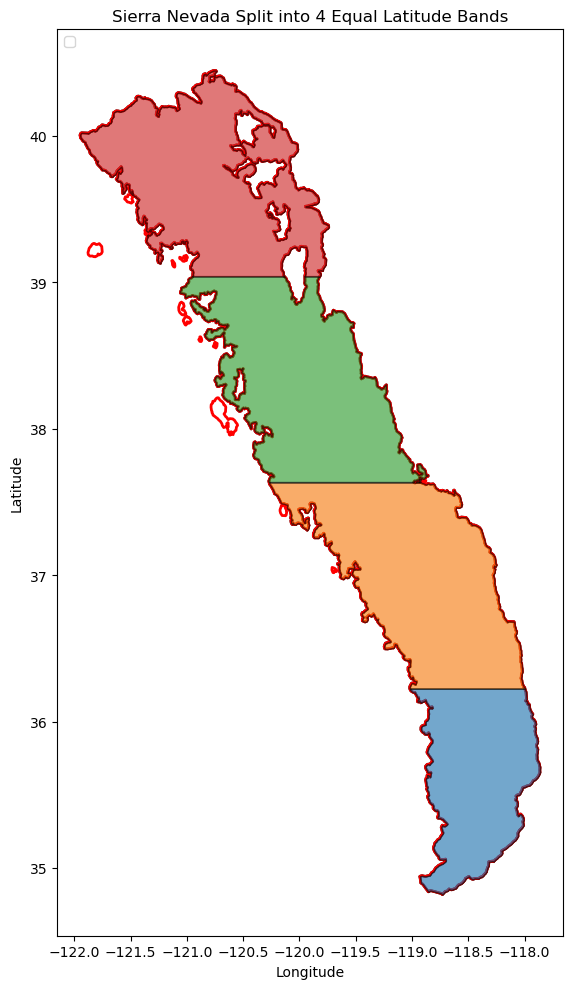

In [92]:
# Plot all 4 regions in different colors
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the original sierra polygon
sierra_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, label='Original Sierra')
sierras.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=2)
sierras_full.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)


# Colors for the 4 regions
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
region_names = ['Region 1 (South)', 'Region 2', 'Region 3', 'Region 4 (North)']

for i, (gdf, color, name) in enumerate(zip(regions_gdf, colors, region_names)):
    gdf.plot(ax=ax, color=color, edgecolor='black', alpha=0.6, label=name)

ax.legend(loc='upper left')
ax.set_title('Sierra Nevada Split into 4 Equal Latitude Bands')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [ ]:
# Download ICESat-2 data for all 4 regions for water years 2019, 2020, and 2021
region_names = ['region_1_south', 'region_2', 'region_3', 'region_4_north']

water_years = {
    'wy2019': ('2018-10-01T00:00:00Z', '2019-09-30T23:59:59Z'),
    'wy2020': ('2019-10-01T00:00:00Z', '2020-09-30T23:59:59Z'),
    'wy2021': ('2020-10-01T00:00:00Z', '2021-09-30T23:59:59Z'),
}

all_data = {}
for wy_name, (start, end) in water_years.items():
    for i, (region, name) in enumerate(zip(regions, region_names)):
        key = f"{name}_{wy_name}"
        print(f"\n--- Downloading {key} ---")
        all_data[key] = download_icesat2(region, start, end)
        all_data[key]['region'] = name
        all_data[key]['water_year'] = wy_name
        print(f"{key}: {all_data[key].shape[0]} points downloaded")

# Combine all data into a single GeoDataFrame and sort by time index
import pandas as pd
combined_gdf = pd.concat(all_data.values(), ignore_index=False)
combined_gdf = combined_gdf.sort_index()
print(f"\nCombined GeoDataFrame: {combined_gdf.shape[0]} total points")


--- Downloading region_1_south_wy2019 ---
Completed in 34.837 seconds of wall-clock time
Reference Ground Tracks: [ 562  646 1004 1149   59  120  143  204 1088 1065]
Cycles: [1 2 3 4 5]
Received 316589 elevations
region_1_south_wy2019: 316589 points downloaded

--- Downloading region_2_wy2019 ---
Completed in 49.105 seconds of wall-clock time
Reference Ground Tracks: [ 242  265  562  623  646  684  707  768 1004 1065 1126 1149 1210   59
  120  181  204 1088]
Cycles: [1 2 3 4 5]
Received 567311 elevations
region_2_wy2019: 567311 points downloaded

--- Downloading region_3_wy2019 ---
Completed in 45.656 seconds of wall-clock time
Reference Ground Tracks: [ 242  265  303  326  623  684  707  768 1126 1149 1210  181  204  829
 1271 1065  745]
Cycles: [1 2 3 4]
Received 470781 elevations
region_3_wy2019: 470781 points downloaded

--- Downloading region_4_north_wy2019 ---
Completed in 33.919 seconds of wall-clock time
Reference Ground Tracks: [ 242  265  303  326  387  745  768  806  890 11

In [ ]:
combined_gdf.to_pickle('../data/icesat2/sierras_gdf_2018_2021_atl06_01312026.pkl')

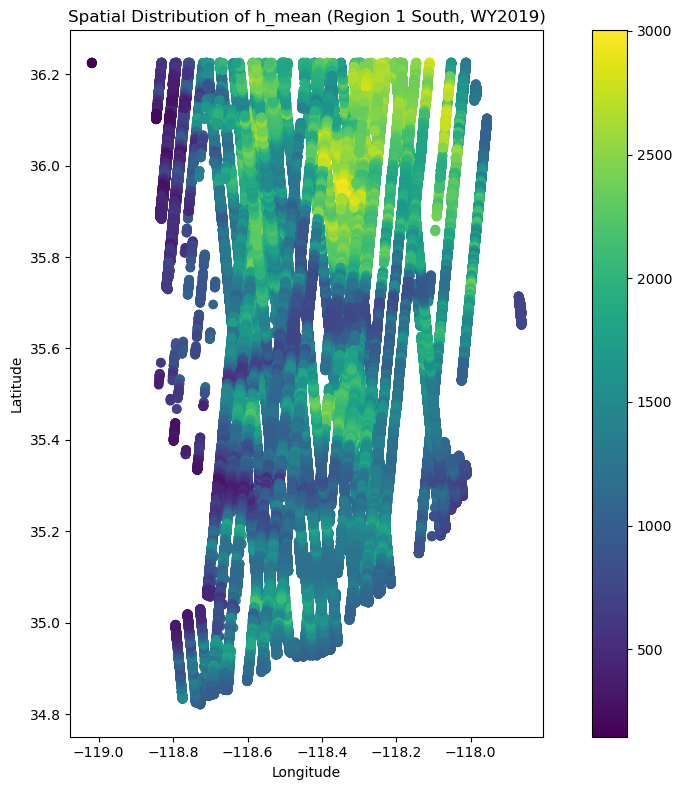

In [ ]:
# Plot the spatial distribution of h_mean for the southernmost region
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
wy2019_data['region_1_south'].plot(column='h_mean', ax=ax, legend=True, cmap='viridis')
ax.set_title('Spatial Distribution of h_mean (Region 1 South, WY2019)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

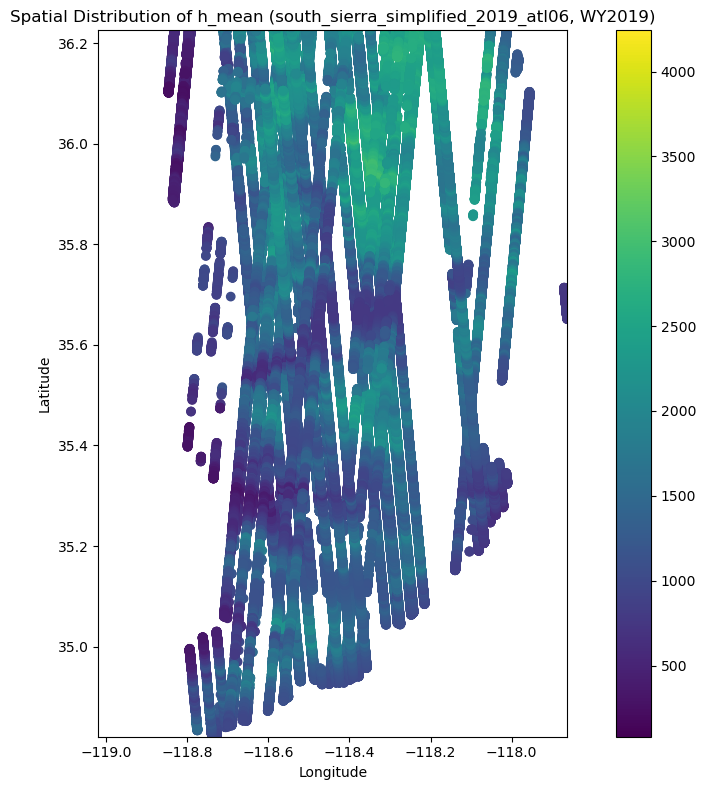

In [ ]:
# Plot the spatial distribution of h_mean for south_sierra_simplified_2019_atl06 (same area as region_1_south)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
south_sierra_simplified_2019_atl06.plot(column='h_mean', ax=ax, legend=True, cmap='viridis')
ax.set_title('Spatial Distribution of h_mean (south_sierra_simplified_2019_atl06, WY2019)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set axis limits to match region_1_south
xlim = wy2019_data['region_1_south'].total_bounds[[0, 2]]
ylim = wy2019_data['region_1_south'].total_bounds[[1, 3]]
ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.tight_layout()
plt.show()